In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys


DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_with_track_id_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_with_track_id_pixel_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)


# Only use pixel data
X = np.concatenate([bg_pixel_spacetime, sig_pixel_spacetime], axis=0)
y = np.concatenate(
    [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_pixel_spacetime))], axis=0
)

X_xyz = X[:, :, :3]
X_t = X[:, :, -1]
layer = X[:, :, 3]
track_id = X[:, :, 4]
X = np.concatenate([X_xyz, X_t[:, :, None]], axis=-1)

shuffled_indices = np.random.permutation(len(X))
X = X[shuffled_indices]
y = y[shuffled_indices]
track_id = track_id[shuffled_indices]
del X_xyz, X_t, layer
del bg_pixel_spacetime, sig_pixel_spacetime

import torch
from torch_geometric.data import Data


def batch_events_to_variable_graphs(events: torch.Tensor, track_ids: torch.Tensor, layer_ids: torch.Tensor = None):
    all_graphs = []
    event_indices = []

    for event_idx, event in enumerate(events):
        event_mask = event[:, -1] != -1
        valid_hits = event[event_mask]
        valid_track_ids = track_ids[event_idx][event_mask]
        if layer_ids is not None:
            valid_layer_ids = layer_ids[event_idx][event_mask]

        times = valid_hits[:, -1]
        positions = valid_hits[:, :3]

        unique_times = np.unique(times)
        for t in unique_times:
            time_mask = times == t
            time_masked_masked_positions = positions[time_mask]
            time_masked_track_ids = valid_track_ids[time_mask]
            if layer_ids is not None:
                time_masked_layer_ids = valid_layer_ids[time_mask]

            num_nodes = time_masked_masked_positions.size(0)
            if num_nodes < 2:
                continue
            if np.unique(time_masked_track_ids.cpu()).size < 2:
                continue
            nodes = time_masked_masked_positions
            row, col = torch.triu_indices(num_nodes, num_nodes, offset=1)

            if layer_ids is not None:
                edge_mask = np.abs(time_masked_layer_ids[row] - time_masked_layer_ids[col]) <= 1
                row = row[edge_mask]
                col = col[edge_mask]

            # compute labels: same non-zero track
            labels = (time_masked_track_ids[row] > 0) & (
                time_masked_track_ids[row] == time_masked_track_ids[col]
            )

            labels = labels.to(torch.float)

            edge_index = torch.stack([row, col], dim=0)

            all_graphs.append(Data(x=nodes, edge_index=edge_index, edge_labels=labels))
            event_indices.append(event_idx)
    # Batch all graphs together
    if len(all_graphs) == 0:
        raise ValueError("No valid graphs were created from the input events.")
        return None
    return all_graphs, torch.tensor(event_indices, dtype=torch.long)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, track_id_train, track_id_val = train_test_split(
    X, y, track_id, test_size=0.2, random_state=42, stratify=y
)

del X, y  # , track_id  # Free up memory (if needed


train_graphs, train_event_indices = batch_events_to_variable_graphs(
    torch.tensor(X_train, dtype=torch.float),
    torch.tensor(track_id_train, dtype=torch.long),
)
val_graphs,train_event_indices = batch_events_to_variable_graphs(
    torch.tensor(X_val, dtype=torch.float), torch.tensor(track_id_val, dtype=torch.long)
)
del (
    X_train,
    X_val,
    track_id_train,
    track_id_val,
)  # Free up memory (if needed)


from torch_geometric.loader import DataLoader
import torch
from torch_geometric.data import Batch, Dataset

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)

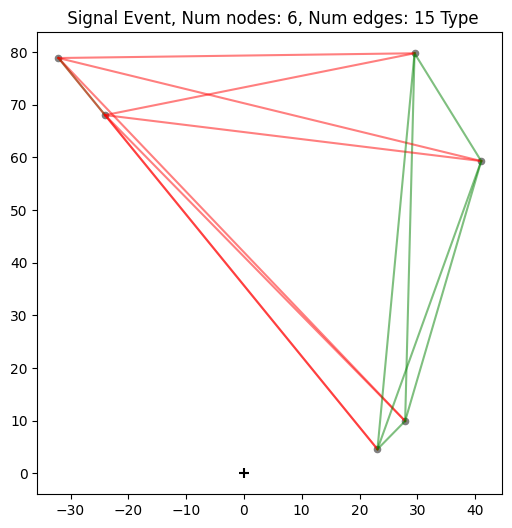

In [29]:
event_index = 5
event_indices = train_event_indices[event_index]
nodes = train_graphs[event_index].x
edge_index = train_graphs[event_index].edge_index
truth_edges = train_graphs[event_index].edge_labels

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(nodes[:, 0], nodes[:, 1], c="grey", s=20)
for i in range(edge_index.size(1)):
    n1 = edge_index[0, i]
    n2 = edge_index[1, i]
    if truth_edges[i] > 0:
        ax.plot(
            [nodes[n1, 0], nodes[n2, 0]],
            [nodes[n1, 1], nodes[n2, 1]],
            c="green",
            alpha=0.5,
        )
    else:
        ax.plot(
            [nodes[n1, 0], nodes[n2, 0]],
            [nodes[n1, 1], nodes[n2, 1]],
            c="red",
            alpha=0.5,
        )
event_label = "Signal" if y_train[event_index] == 1 else "Background"

ax.set_title(
    f" {event_label} Event, Num nodes: {nodes.size(0)}, Num edges: {edge_index.size(1)} Type"
)
ax.scatter([0], [0], c="black", s=50, marker="+")  # Detector center
plt.show()

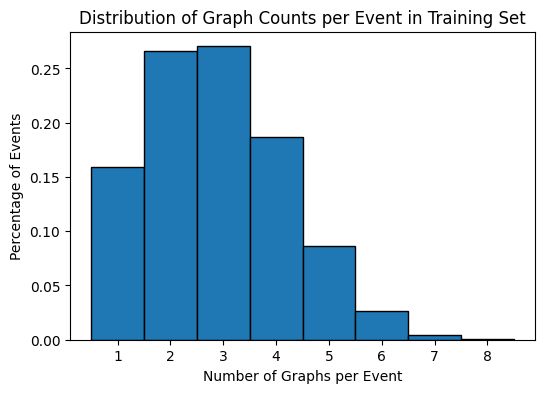

In [33]:
counts = torch.unique(train_event_indices, return_counts=True)[1].numpy().astype(np.float32)
bins = np.arange(counts.min(), counts.max() + 2)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
hist, bins = np.histogram(counts, bins=bins)
hist = hist / hist.sum()  # Normalize to form a probability distribution
ax.bar(bins[:-1], hist, width=1, align='edge', edgecolor='black', alpha=1.0, color='tab:blue')
ax.set_xticks((bins[:-1] + bins[1:]) / 2)
ax.set_xticklabels([str(int(b)) for b in bins[:-1]])
ax.set_xlabel("Number of Graphs per Event")
ax.set_ylabel("Percentage of Events")
ax.set_title("Distribution of Graph Counts per Event in Training Set")
fig.savefig(f"{PLOTS_DIR}/graph_counts_per_event_distribution.png")

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('..')

class ToyGraphDataset(Dataset):
    def __init__(self, graphs):
        super().__init__()
        self.graphs = graphs

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]



def improved_train_model_with_diagnostics():
    """
    Enhanced training with better regularization and detailed diagnostics.
    """
    print("Creating toy data with better balance...")
        
    # Analyze class balance
    analyze_class_balance(train_graphs, val_graphs)
    
    # Create datasets and dataloaders
    
    # Smaller batch sizes to help with generalization
    
    # Get feature dimensions
    sample_graph = train_graphs[0]
    node_input_dim = sample_graph.x.shape[1]
    
    
    print(f"Node feature dimension: {node_input_dim}")
    
    # Create model with better regularization
    model = create_regularized_model(node_input_dim)
    
    print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
    
    # Enhanced training setup
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    
    # Use focal loss to handle class imbalance
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    
    # Training with detailed monitoring
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_auc': [], 'val_auc': [],
        'train_ap': [], 'val_ap': [],
        'lr': []
    }
    
    num_epochs = 20
    best_val_auc = 0.0
    patience_counter = 0
    patience = 15
    
    for epoch in range(num_epochs):
        # Training phase
        train_metrics = train_epoch(model, train_loader, optimizer, criterion)
        
        # Validation phase
        val_metrics = validate_epoch(model, val_loader, criterion)
        
        # Update learning rate
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store metrics
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_auc'].append(train_metrics['auc'])
        history['val_auc'].append(val_metrics['auc'])
        history['train_ap'].append(train_metrics['ap'])
        history['val_ap'].append(val_metrics['ap'])
        history['lr'].append(current_lr)
        
        # Early stopping based on validation AUC
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
        
        # Print progress
        if epoch % 10 == 0 or epoch < 20:
            print(f'Epoch {epoch:3d}: '
                  f'Train Loss: {train_metrics["loss"]:.4f}, Val Loss: {val_metrics["loss"]:.4f} | '
                  f'Train AUC: {train_metrics["auc"]:.4f}, Val AUC: {val_metrics["auc"]:.4f} | '
                  f'LR: {current_lr:.6f}')
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    print(f'\nBest validation AUC: {best_val_auc:.4f}')
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    
    # Comprehensive evaluation
    plot_comprehensive_training_curves(history)
    final_metrics = comprehensive_evaluation(model, train_loader, val_loader)
    
    return model, history, final_metrics



class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    """
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        p_t = torch.where(targets == 1, inputs, 1 - inputs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        
        focal_loss = alpha_t * (1 - p_t) ** self.gamma * bce_loss
        return focal_loss.mean()


def create_regularized_model(node_input_dim):
    """
    Create model with better regularization to prevent overfitting.
    """
    from src_gnn.model.components import EdgeClassificationNet
    
    model = EdgeClassificationNet(
        node_input_dim=node_input_dim,
        edge_hidden_dim=12,  # Smaller to reduce overfitting
        node_hidden_dim=24,  # Smaller to reduce overfitting
        num_conv_layers=3,   # Fewer layers
        dropout=0.2,         # Higher dropout
        edge_init_layers=2,  # Simpler edge initialization
        batch_norm=True
    )
    
    return model


def train_epoch(model, train_loader, optimizer, criterion):
    """
    Train for one epoch with detailed metrics.
    """
    model.train()
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probs = []
    
    for batch in train_loader:
        optimizer.zero_grad()
        
        probs = model(batch.x, batch.edge_index)
        loss = criterion(probs, batch.edge_labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        total_loss += loss.item()
        
        # Store predictions for metrics
        with torch.no_grad():
            predictions = (probs > 0.5).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(batch.edge_labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5
    ap = average_precision_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5
    
    return {
        'loss': total_loss / len(train_loader),
        'accuracy': accuracy,
        'auc': auc,
        'ap': ap
    }


def validate_epoch(model, val_loader, criterion):
    """
    Validate for one epoch with detailed metrics.
    """
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in val_loader:
            probs = model(batch.x, batch.edge_index)
            loss = criterion(probs, batch.edge_labels)
            
            total_loss += loss.item()
            
            predictions = (probs > 0.5).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(batch.edge_labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5
    ap = average_precision_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5
    
    return {
        'loss': total_loss / len(val_loader),
        'accuracy': accuracy,
        'auc': auc,
        'ap': ap
    }


def analyze_class_balance(train_graphs, val_graphs):
    """
    Analyze class balance in the datasets.
    """
    train_pos = sum(graph.edge_labels.sum().item() for graph in train_graphs)
    train_total = sum(len(graph.edge_labels) for graph in train_graphs)
    
    val_pos = sum(graph.edge_labels.sum().item() for graph in val_graphs)
    val_total = sum(len(graph.edge_labels) for graph in val_graphs)
    
    print(f"\n=== Class Balance Analysis ===")
    print(f"Training: {train_pos}/{train_total} positive ({train_pos/train_total:.2%})")
    print(f"Validation: {val_pos}/{val_total} positive ({val_pos/val_total:.2%})")


def plot_comprehensive_training_curves(history):
    """
    Plot comprehensive training diagnostics.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(len(history['train_loss']))
    
    # Loss curves
    axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', alpha=0.8)
    axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss', alpha=0.8)
    axes[0, 0].set_title('Loss Curves')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC curves
    axes[0, 1].plot(epochs, history['train_auc'], label='Train AUC', alpha=0.8)
    axes[0, 1].plot(epochs, history['val_auc'], label='Val AUC', alpha=0.8)
    axes[0, 1].set_title('AUC Curves')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Average Precision curves
    axes[0, 2].plot(epochs, history['train_ap'], label='Train AP', alpha=0.8)
    axes[0, 2].plot(epochs, history['val_ap'], label='Val AP', alpha=0.8)
    axes[0, 2].set_title('Average Precision Curves')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Average Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1, 0].plot(epochs, history['train_acc'], label='Train Acc', alpha=0.8)
    axes[1, 0].plot(epochs, history['val_acc'], label='Val Acc', alpha=0.8)
    axes[1, 0].set_title('Accuracy Curves')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    axes[1, 1].plot(epochs, history['lr'], alpha=0.8)
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
    
    # Gap analysis (overfitting indicator)
    train_val_gap = np.array(history['train_auc']) - np.array(history['val_auc'])
    axes[1, 2].plot(epochs, train_val_gap, alpha=0.8, color='red')
    axes[1, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 2].set_title('Overfitting Gap (Train AUC - Val AUC)')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('AUC Gap')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def comprehensive_evaluation(model, train_loader, val_loader):
    """
    Comprehensive model evaluation.
    """
    print("\n=== Comprehensive Evaluation ===")
    
    # Evaluate on both train and validation
    train_metrics = validate_epoch(model, train_loader, nn.BCELoss())
    val_metrics = validate_epoch(model, val_loader, nn.BCELoss())
    
    print(f"Final Train Metrics:")
    print(f"  Accuracy: {train_metrics['accuracy']:.4f}")
    print(f"  AUC: {train_metrics['auc']:.4f}")
    print(f"  Average Precision: {train_metrics['ap']:.4f}")
    
    print(f"Final Validation Metrics:")
    print(f"  Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  AUC: {val_metrics['auc']:.4f}")
    print(f"  Average Precision: {val_metrics['ap']:.4f}")
    
    # Overfitting analysis
    auc_gap = train_metrics['auc'] - val_metrics['auc']
    ap_gap = train_metrics['ap'] - val_metrics['ap']
    
    print(f"\nOverfitting Analysis:")
    print(f"  AUC Gap (Train - Val): {auc_gap:.4f}")
    print(f"  AP Gap (Train - Val): {ap_gap:.4f}")
    
    if auc_gap > 0.1:
        print("  ⚠️  Significant overfitting detected!")
    elif auc_gap > 0.05:
        print("  ⚠️  Mild overfitting detected")
    else:
        print("  ✅ Good generalization")
    
    return {
        'train': train_metrics,
        'val': val_metrics,
        'gaps': {'auc_gap': auc_gap, 'ap_gap': ap_gap}
    }


print("Starting improved training with diagnostics...")
model, history, final_metrics = improved_train_model_with_diagnostics()

print("\n" + "="*50)
print("Training completed!")


Starting improved training with diagnostics...
Creating toy data with better balance...

=== Class Balance Analysis ===
Training: 79398663.0/162907752 positive (48.74%)
Validation: 19599240.0/40287186 positive (48.65%)
Node feature dimension: 3
Model created with 47881 parameters
Epoch   0: Train Loss: 0.0528, Val Loss: 0.0450 | Train AUC: 0.8447, Val AUC: 0.8989 | LR: 0.000976
Epoch   1: Train Loss: 0.0483, Val Loss: 0.0435 | Train AUC: 0.8744, Val AUC: 0.9073 | LR: 0.000905
Epoch   2: Train Loss: 0.0470, Val Loss: 0.0450 | Train AUC: 0.8819, Val AUC: 0.9097 | LR: 0.000794
Epoch   3: Train Loss: 0.0462, Val Loss: 0.0419 | Train AUC: 0.8863, Val AUC: 0.9156 | LR: 0.000655
Epoch   4: Train Loss: 0.0456, Val Loss: 0.0417 | Train AUC: 0.8897, Val AUC: 0.9171 | LR: 0.000500
Epoch   5: Train Loss: 0.0451, Val Loss: 0.0419 | Train AUC: 0.8925, Val AUC: 0.9173 | LR: 0.000345
Epoch   6: Train Loss: 0.0446, Val Loss: 0.0418 | Train AUC: 0.8948, Val AUC: 0.9184 | LR: 0.000206
Epoch   7: Train Lo

KeyboardInterrupt: 